# Dynamic characterization with [`dynamic_characterization`](https://github.com/brightway-lca/dynamic_characterization) package.

**Static** LCIA assigns each environmental flow a single, fixed characterization factor (CF): e.g. for climate change and $GWP_{100}$): "1 kg CH4 = 29.8 kg CO2-eq", regardless of when the environmental flow is emitted.

**Dynamic characterization** instead assesses the impact as a function of *when* an environmental flow occurs and *how much time has passed since*.

**Plan for this session:**
1. Data structure expected by `dynamic_characterization`
2. Match, apply and explore available climate change characterization functions
3. Effect of fixed vs. flexible time horizons
4. Instantaneous (radiative forcing), vs. cumulative and normalized metrics (GWP)
5. Short dive into prospective-dynamic LCIA 
6. Build and play with your own characterization functions


## 1. The data structure

[`dynamic_characterization`](https://github.com/brightway-lca/dynamic_characterization) works with a simple input format for the inventories/environmental flows: 

a `pandas.DataFrame` with 4 columns: `date`, `amount`, `flow`, `activity`. 

This temporalized inventory can come from [`bw_temporalis`](https://github.com/brightway-lca/bw_temporalis), [`bw_timex`](https://github.com/brightway-lca/bw_timex) or another source. The format just needs to align.

| date | amount | flow | activity |
|-------|-------|------|----------|
| 101   | 33    | 1    | 2        |
| 312   | 21    | 4    | 2        |

A **characterization function** takes *one row* of this dataframe (i.e. one emission at one point in time) and transforms it. 

Applying a very simple function to both rows above could give:

| date | amount | flow | activity |
|------|--------|------|----------|
| 101  | 33     | 1    | 2        |
| 102  | 25     | 1    | 2        |
| 103  | 20     | 1    | 2        |
| 312  | 21     | 4    | 2        |
| 313  | 20     | 4    | 2        |
| 314  | 19     | 4    | 2        |

One row in, several rows out: 
the inventory flow gets spread out (and reshaped) over time. 

Actual characterization functions are usually complex. For climate change, `dynamic_characterization` implements the decay functions and radiative efficiencies of GHGs from the [IPCC AR6](https://www.ipcc.ch/assessment-report/ar6/)  report.

In [1]:
import pandas as pd

# a dummy dynamic inventory
simple_dynamic_inventory = pd.DataFrame(
    data={
        "date": pd.Series(
            data=["01-01-2025", "01-01-2035", "01-01-2040",],
            dtype="datetime64[s]",
        ),
        "amount": pd.Series(data=[20, 15, 0.3], dtype="float64"), #kg
        "flow": pd.Series(data=[1, 1, 3], dtype="int"), #e.g. CO2, CO2, CH4
        "activity": pd.Series(data=[2, 2, 4], dtype="int"),
    }
)

simple_dynamic_inventory

,date,amount,flow,activity
0,2025-01-01,20.0,1,2
1,2035-01-01,15.0,1,2
2,2040-01-01,0.3,3,4


## 2. Match and explore available characterization functions

In [2]:
import dynamic_characterization.ipcc_ar6 as ar6
ar6.characterize_ch4 

<function dynamic_characterization.ipcc_ar6.radiative_forcing.characterize_ch4(series, period: int = 100, cumulative=False) -> dynamic_characterization.classes.CharacterizedRow>

-  it takes a `series` (i.e. one row of the DataFrame above), and a `period` (how long to look ahead), plus some additional input arguments, 
- it returns a `CharacterizedRow`, which is an output structured in the same way as the input (`date`/`amount`/`flow`/`activity`) but now describing the time series of impacts caused by that one emission over the `period`.

We can combine the characterization of the different GHGs in a dynamic inventory dataframe a "wrapper" `characterize()`. #TODO1 check if wrapper is correct word

In [3]:
from dynamic_characterization import characterize
characterize?

Signature:
characterize(
    dynamic_inventory_df: pandas.core.frame.DataFrame,
    metric: str = 'radiative_forcing',
    characterization_functions: Dict[int, Callable] = None,
    base_lcia_method: Tuple[str, ...] = None,
    time_horizon: int = 100,
    fixed_time_horizon: bool = False,
    time_horizon_start: datetime.datetime = datetime.datetime(2026, 9, 16, 15, 5, 22, 87694),
    characterization_function_co2: Callable = None,
    time_varying_re: bool = False,
    fallback_to_ipcc: bool = True,
    characterize_biogenic_uptake: bool = True,
) -> pandas.core.frame.DataFrame
Docstring:
Characterizes the dynamic inventory, formatted as a Dataframe, by evaluating each emission (row in DataFrame) using given dynamic characterization functions.

Available metrics are radiative forcing [W/m2] and GWP [kg CO2eq], defaulting to `radiative_forcing`.
Additional prospective metrics pGWP, pGTP, and prospective_radiative_forcing use Watanabe et al. (2026)
scenario-based characterization fact

`characterize` requires a `characterization_functions`-dictionary, which tells the method which characterization function to use for which environmental flow.

This is given for all ecoinvent biosphere flows, but we manually have to assign it for our simple inventory above:

In [4]:
#SOLUTION
characterized_dynamic_inventory = characterize(
        simple_dynamic_inventory,
        metric="radiative_forcing",  #also available: GWP, and some prospective variants (more later)
        characterization_functions={
            1: ar6.characterize_co2, #flow_id : characterization function
            3: ar6.characterize_ch4,
        },
        time_horizon=4, #years (exclusive last year)
    )


In [5]:
characterized_dynamic_inventory

,date,amount,flow,activity
0,2026-01-01 05:49:12,3.294405e-14,1,2
1,2027-01-01 11:38:24,3.092531e-14,1,2
2,2028-01-01 17:27:36,2.927490e-14,1,2
3,2036-01-01 05:49:12,2.470804e-14,1,2
4,2036-12-31 11:38:24,2.319398e-14,1,2
5,2037-12-31 17:27:36,2.195618e-14,1,2
6,2040-12-31 05:49:12,5.766701e-14,3,4
7,2041-12-31 11:38:24,5.298133e-14,3,4
8,2042-12-31 17:27:36,4.867637e-14,3,4


Let's look at a slightly larger system using `bw_timex`: 1 activity `A`, emitting 3 environmental flows CH4, CO2, N2O over time:

In [6]:
import bw2data as bd
import numpy as np
from bw_temporalis import TemporalDistribution

def write_database_multi_emission():

    project_name = "test_project"
    if project_name in bd.projects:
        bd.projects.delete_project(project_name)

    bd.projects.set_current(project_name)

    bd.Database("dummy-bio").write(
        {
            ("dummy-bio", "CH4"): {
                "type": "emission",
                "name": "methane",
                "dummy code": "ch4",
            },
            ("dummy-bio", "CO2"): {
                "type": "emission",
                "name": "carbon dioxide",
                "dummy code": "co2",
            },
            ("dummy-bio", "N2O"): {
                "type": "emission",
                "name": "nitrious oxide",
                "dummy code": "n2o",
            },
        }
    )

    bd.Database(
        "test"
    ).write(  # dummy system containing 1 activity with multiple emissions
        {
            ("test", "A"): {
                "name": "A",
                "location": "somewhere",
                "reference product": "a",
                "exchanges": [
                    {
                        "amount": 1,
                        "type": "production",
                        "input": ("test", "A"),
                    },
                    {
                        "amount": 0.5,
                        "type": "biosphere",
                        "input": ("dummy-bio", "CH4"),
                        "temporal_distribution": TemporalDistribution(
                            date=np.array([10, 15], dtype="timedelta64[Y]"),
                            amount=np.array([0.5, 0.5]),
                        ),  # emission of CH4 10 and 15 years after execution of process A
                    },
                    {
                        "amount": 20,
                        "type": "biosphere",
                        "input": ("dummy-bio", "CO2"),
                        "temporal_distribution": TemporalDistribution(
                            date=np.array([-10, -5], dtype="timedelta64[Y]"),
                            amount=np.array([0.5, 0.5]),
                        ),  # emission of CO2 10 and 5 years before
                    },
                    {
                        "amount": 0.05,
                        "type": "biosphere",
                        "input": ("dummy-bio", "N2O"),
                        "temporal_distribution": TemporalDistribution(
                            date=np.array([0], dtype="timedelta64[Y]"),
                            amount=np.array([1]),
                        ),  # emission of N2O at the same time
                    },
                ],
            },
        }
    )

    bd.Method(("GWP", "example")).write(
        [
            (("dummy-bio", "CH4"), 29.8),  # GWP100 from IPCC AR6
            (("dummy-bio", "N2O"), 273),
            (("dummy-bio", "CO2"), 1),
        ]
    )

we create the project and write the data:

In [7]:
write_database_multi_emission()

100%|██████████| 3/3 [00:00<?, ?it/s]


Vacuuming database 
Not able to determine geocollections for all datasets. This database is not ready for regionalization.


100%|██████████| 1/1 [00:00<?, ?it/s]

Vacuuming database 


we calculate a timex_lca object:

In [8]:
#SOLUTION
from datetime import date

from bw_timex import TimexLCA
demand = {("test", "A"): 1}
gwp = ("GWP", "example")

tlca = TimexLCA(demand, gwp)
tlca.build_timeline(starting_datetime = date(2026, 9, 16), temporal_grouping="day") #starting date of the timeline
tlca.lci()
tlca.static_lcia()

2026-09-16 15:05:25.981 | INFO     | bw_timex.timex_lca:__init__:120 - No database_dates provided. Treating the databases containing the functional                 unit as dynamic. No remapping of inventories to time explicit databases will be done.
2026-09-16 15:05:26.170 | INFO     | bw_timex.timex_lca:build_timeline:217 - No edge filter function provided. Skipping all edges in background databases.
2026-09-16 15:05:26.202 | INFO     | bw_timex.timeline_builder:add_column_temporal_market_shares_to_timeline:393 - No time-explicit databases are provided. Mapping to time-explicit databases is not possible.


Starting graph traversal
Calculation count: 0


In [9]:
tlca.timeline

,hash_producer,time_mapped_producer,date_producer,producer,producer_name,hash_consumer,time_mapped_consumer,date_consumer,consumer,consumer_name,amount,temporal_market_shares
0,20260916,17,2026-09-16,16,A,20260916,-1,2026-09-16,-1,-1,1.0,None


Let's look at this dynamic inventory dataframe. It has exactly the structure that we talked about:

In [10]:
#SOLUTION
tlca.dynamic_inventory_df

,date,amount,flow,activity
2,2016-09-15 13:48:00,10.00,14,17
3,2021-09-15 18:54:00,10.00,14,17
4,2026-09-16 00:00:00,0.05,15,17
0,2036-09-15 10:12:00,0.25,13,17
1,2041-09-15 15:18:00,0.25,13,17


let's compute the radiative forcing again, this time over 100 instead of 3 years. We need a mapping between flows and characterization functions, and then the 'characterize()' wrapper.

In [11]:
#SOLUTION
characterization_functions = {
    bd.get_node(code="CH4").id: ar6.characterize_ch4,
    bd.get_node(code="CO2").id: ar6.characterize_co2,
    bd.get_node(code="N2O").id: ar6.characterize_n2o,
} 

characterized_df = characterize(
    tlca.dynamic_inventory_df,
    metric="radiative_forcing",
    characterization_functions=characterization_functions,
    time_horizon=100,  # years (exclusive last year)
) 

In [12]:
characterized_df

,date,amount,flow,activity
0,2017-09-15 19:37:12,1.647203e-14,14,17
1,2018-09-16 01:26:24,1.546265e-14,14,17
2,2019-09-16 07:15:36,1.463745e-14,14,17
3,2020-09-15 13:04:48,1.395887e-14,14,17
4,2021-09-15 18:54:00,1.339711e-14,14,17
...,...,...,...,...
490,2136-09-15 16:12:00,1.667678e-17,13,17
491,2137-09-15 22:01:12,1.532172e-17,13,17
492,2138-09-16 03:50:24,1.407677e-17,13,17
493,2139-09-16 09:39:36,1.293297e-17,13,17


conveniently, this is built into `bw_timex`, so we can use the internal functions directly, with the same input arguments as before

In [13]:
tlca.dynamic_lcia?

Signature:
tlca.dynamic_lcia(
    metric: str = 'radiative_forcing',
    time_horizon: int = 100,
    fixed_time_horizon: bool = False,
    time_horizon_start: datetime.datetime = None,
    characterization_functions: dict = None,
    characterization_function_co2: dict = None,
    use_disaggregated_lci: bool = False,
) -> pandas.core.frame.DataFrame
Docstring:
Calculates dynamic LCIA with the `DynamicCharacterization` class using the dynamic inventory
and dynamic characterization functions. Dynamic characterization is handled by the separate
package `dynamic_characterization` (https://dynamic-characterization.readthedocs.io).

Dynamic characterization functions in the form of a dictionary {biosphere_flow_database_id:
characterization_function} can be given by the user.
If none are given, a set of default dynamic characterization functions based on IPCC AR6 are
provided from `dynamic_characterization` package. These are mapped to the biosphere3 flows
of the chosen static climate change

Let's apply `bw_timex`'s method directly:

In [14]:
#SOLUTION
tlca.dynamic_lcia(
    metric="radiative_forcing",
    characterization_functions=characterization_functions, 
    time_horizon=100)

,date,amount,flow,activity
0,2018-01-01 05:49:12,1.647203e-14,14,17
1,2019-01-01 11:38:24,1.546265e-14,14,17
2,2020-01-01 17:27:36,1.463745e-14,14,17
3,2020-12-31 23:16:48,1.395887e-14,14,17
4,2022-01-01 05:06:00,1.339711e-14,14,17
...,...,...,...,...
490,2137-01-01 00:54:00,1.667678e-17,13,17
491,2138-01-01 06:43:12,1.532172e-17,13,17
492,2139-01-01 12:32:24,1.407677e-17,13,17
493,2140-01-01 18:21:36,1.293297e-17,13,17


we can plot the dynamic characterized inventory

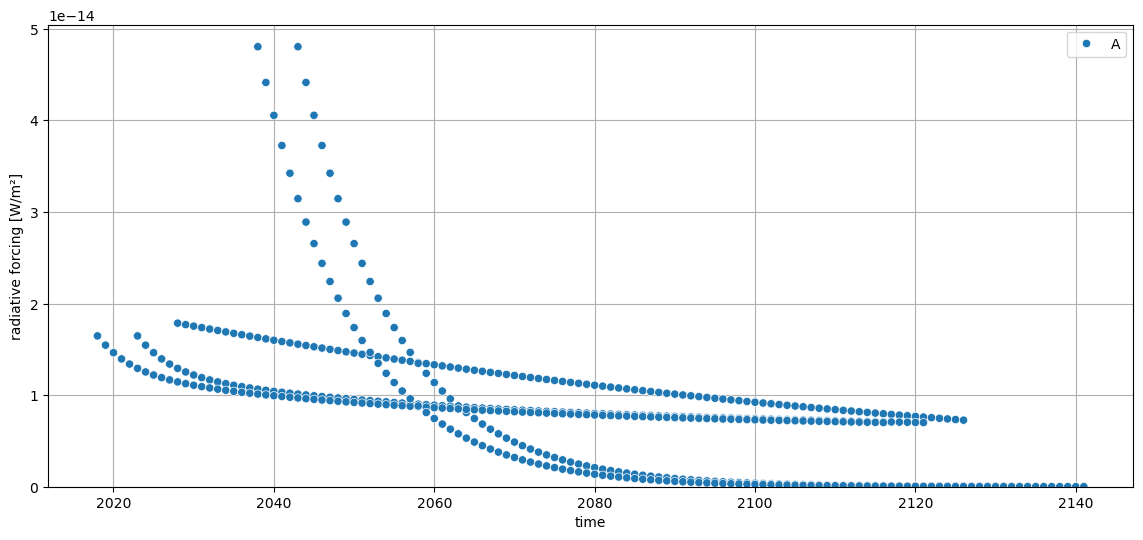

characterized dynamic score: 4.121262160040557e-12


In [15]:
tlca.plot_dynamic_characterized_inventory() #TODO: add colour by flow 
print(
    f"characterized dynamic score: {tlca.dynamic_score}"
)

Above, you can see:
1) that different emissions start at the different times like we defined in our system
2) their metric (radiative forcing) is evaluated each 100 years (`time_horizon`) starting from the individual timings of emission. So for an emission in 2026 from 2026 to 2126, while for an emission in 2045 from 2045 to 2145.
3) They decay at different rates because they are different GHGs with different lifetimes.
4) Their warming effect differs due to their different ability to trap heat (radiative efficiencies) 


## 3. Fixed vs. flexible time horizon


Is it consistent to evaluate later emissions for the same duration as earlier emissions? 

Maybe not, so there is also the option to set `fixed_time_horizon`= `True`, which means that all emissions are considered until the same end year.


In [16]:
tlca.dynamic_lcia??

Signature:
tlca.dynamic_lcia(
    metric: str = 'radiative_forcing',
    time_horizon: int = 100,
    fixed_time_horizon: bool = False,
    time_horizon_start: datetime.datetime = None,
    characterization_functions: dict = None,
    characterization_function_co2: dict = None,
    use_disaggregated_lci: bool = False,
) -> pandas.core.frame.DataFrame
Source:   
    def dynamic_lcia(
        self,
        metric: str = "radiative_forcing",
        time_horizon: int = 100,
        fixed_time_horizon: bool = False,
        time_horizon_start: datetime = None,
        characterization_functions: dict = None,
        characterization_function_co2: dict = None,
        use_disaggregated_lci: bool = False,
    ) -> pd.DataFrame:
        """
        Calculates dynamic LCIA with the `DynamicCharacterization` class using the dynamic inventory
        and dynamic characterization functions. Dynamic characterization is handled by the separate
        package `dynamic_characterization` (https://dyn

characterized dynamic score: 4.224714931682254e-12


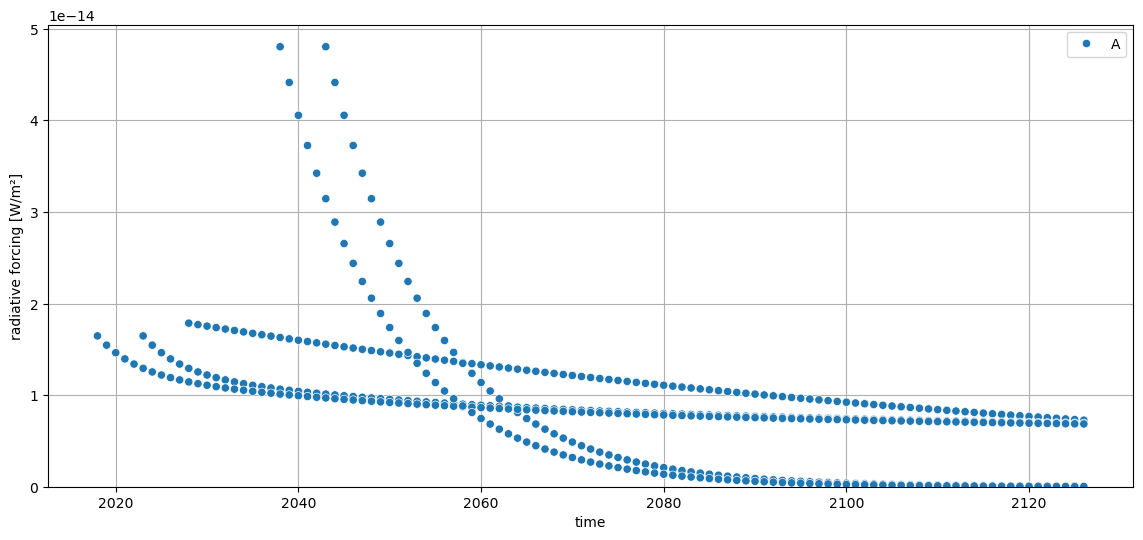

In [17]:
tlca.dynamic_lcia(
    metric="radiative_forcing",
    fixed_time_horizon=True, # All emissions considered to the same end year
    time_horizon=100,
    characterization_functions=characterization_functions,
)

print(
    f"characterized dynamic score: {tlca.dynamic_score}"
)
tlca.plot_dynamic_characterized_inventory()

With `fixed_time_horizon = True`, we evaluate all emissions until the same end date, (default is time of functional unit + `time_horizon`, but it can be defined with `time_horizon_start`), regardless of when they actually occur. 

As our CO2 emissions occur 10 and 5 years earlier than the functional unit, this means that they are assessed for 110 and 105 years, respectively, leading to a higher score than with `fixed_time_horizon = False`.
Similarly, later emissions are assessed for shorter, but this has little effect in our model, as the later emissions (CH4) have almost fully decayed by then.

## 4. RF (instantaneus) vs. GWP (integrated and normalized)


#### Radiative Forcing (RF)

add definition of RF in mark down

### Global warming potential (GWP)


GWP describes the warming of a GHG relative to that of the reference gas CO2: it divides the time-integral of RF of a GHG over a chosen time horizon by the time-integral of RF of CO2 over the same time horizon:

$$\text{GWP}_{TH} = \frac{\displaystyle\int_0^{TH} RF_{\text{gas}}(t)\, dt}{\displaystyle\int_0^{TH} RF_{\text{CO2}}(t)\, dt}$$



GWP can be calculated in `dynamic_characterization` with the same options as RF:

- time horizon can vary (default 100 years)
- fixed or flexible time horizon


Let's evaluate GWP20:


In [18]:
tlca.dynamic_lcia(
    metric="GWP",
    time_horizon=20,
    characterization_functions=characterization_functions,
)

print(
    f"characterized dynamic GWP score: {tlca.dynamic_score}"
)

characterized dynamic GWP score: 74.14407727485602


In [19]:
tlca.dynamic_lcia(
    metric="GWP",
    fixed_time_horizon=True,
    time_horizon=20,
    characterization_functions=characterization_functions,
)

print(
    f"characterized dynamic score: {tlca.dynamic_score}"
)

characterized dynamic score: 60.711810593541344


With `fixed_time_horizon = True` and `time_horizon = 20` years, the difference in results is substantial, as the 5- and 10-years delayed CH4 emissions are only counted for 15 and 10 years (20 year time horizon starting at the functional unit minus emission delay).


Let's compare how changing the length of the time horizon affects the GWP results:


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

gwp_flexible_TH = {}
gwp_fixed_TH = {}
THs = list(range(20, 100, 20)) + [500]  # 20 to 100 TH in steps of 20 years, plus 500 year

for time_horizon in THs: 
    tlca.dynamic_lcia(
        metric="GWP",
        time_horizon=time_horizon,
        fixed_time_horizon=True,
        characterization_functions=characterization_functions,
    )
    gwp_fixed_TH[time_horizon] = tlca.dynamic_score

    tlca.dynamic_lcia(
        metric="GWP",
        time_horizon=time_horizon,
        fixed_time_horizon=False,
        characterization_functions=characterization_functions,
    )
    gwp_flexible_TH[time_horizon] = tlca.dynamic_score

df = pd.DataFrame(
    {
        "Time horizon": list(gwp_fixed_TH.keys()),
        "GWP (fixed time horizon)": list(gwp_fixed_TH.values()),
        "GWP (flexible time horizon)": list(gwp_flexible_TH.values()),
    }
)

df

,Time horizon,GWP (fixed time horizon),GWP (flexible time horizon)
0,20,60.711811,74.144077
1,40,61.999369,60.944071
2,60,55.552244,53.825761
3,80,50.947907,49.511978
4,500,30.205965,29.977030


One can see that a longer time horizon leads to smaller differences between fixed (time horizon starts at FU for all flows) and flexible time horizons (time horizon starts at each emissions seperately). An increase in time horizon also leads to lower overall scores, because the system contains multiple short-lived GHGs, such as CH4 and N2O, whose CO2-equivalence value decreases when assessing longer time horizons.


### 4) Prospective Characterization

[Watanabe et al. (2026)](https://pubs.acs.org/doi/10.1021/acs.est.5c12391) developed prospective characterization factors (pCFs) for climate change under different future GHG emission scenarios. These pCFs have been implemented under `dynamic_characterization.prospective`.

Unlike "standard" dynamic LCIA, prospective characterization uses **scenario-dependent radiative efficiencies** that evolve based on projected atmospheric concentrations.

There is a [separate notebook](https://github.com/brightway-lca/dynamic_characterization/blob/main/notebooks/prospective_dynamic_lcia_demo.ipynb) explaining the use of pCFs in `dynamic_characterization` in detail.

Let's demonstrate the main workings with a simple dynamic inventory linked to ecoinvent biosphere database:



In [21]:
from dynamic_characterization import characterize
import dynamic_characterization.prospective as prospective

In [22]:
import bw2data as bd
import bw2io as bi

bd.projects.set_current("ei312_REMIND_EU") #TODO change to their project name

# Get biosphere flows for CO2 and CH4 from ecoinvent 3.12 biosphere database
co2_flow = bd.get_node(database="ecoinvent-3.12-biosphere", name="Carbon dioxide, fossil", categories=("air",))
ch4_flow = bd.get_node(database="ecoinvent-3.12-biosphere", name="Methane, fossil", categories=("air",))

# create the familiar dynamic inventory dataframe with CO2 and CH4 emissions
prospective_dynamic_inventory = pd.DataFrame( 
    data={
        "date": pd.Series(
            data=["01-01-2030", "01-01-2070", "01-01-2030", "01-01-2070"],
            dtype="datetime64[s]",
        ),
        "amount": pd.Series(data=[0.3, 0.3, 15.0, 15.0], dtype="float64"), #kg
        "flow": pd.Series(data=[ch4_flow.id, ch4_flow.id, co2_flow.id, co2_flow.id], dtype="int64"), # now with brightway flow ids to use default mapping
        "activity": pd.Series(data=[2, 4, 2, 4], dtype="int"),
    }
)
prospective_dynamic_inventory

,date,amount,flow,activity
0,2030-01-01,0.3,267655083611123753,2
1,2070-01-01,0.3,267655083611123753,4
2,2030-01-01,15.0,267655084475150457,2
3,2070-01-01,15.0,267655084475150457,4


In [23]:
method = ("ecoinvent-3.12", "EF v3.1", "climate change", "global warming potential (GWP100)")

In [24]:
# Set prospective scenario for emission trajectories
prospective.set_scenario(iam="MESSAGE", ssp="SSP2", rcp="4.5")

time_horizon = 100

Prospective characterization has the same syntax as before:

In [25]:
# Characterize with Prospective - fixed RE (standard approach)
prospective_fixed_re= characterize(
    prospective_dynamic_inventory ,
    metric="prospective_radiative_forcing", # instead of "radiative_forcing"
    base_lcia_method=method,
    time_horizon=time_horizon,
    fixed_time_horizon=True, # All emissions considered to the same end year
    time_varying_re=False,  # RE fixed at emission year
)

2026-09-16 15:05:29.013 | INFO     | dynamic_characterization.dynamic_characterization:characterize:135 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


In [26]:
prospective_fixed_re

,date,amount,flow,activity
0,2031-01-01 05:49:12,2.236328e-14,267655084475150457,2
1,2031-01-01 05:49:12,4.088020e-14,267655083611123753,2
2,2032-01-01 11:38:24,2.136563e-14,267655084475150457,2
3,2032-01-01 11:38:24,3.755851e-14,267655083611123753,2
4,2032-12-31 17:27:36,2.047596e-14,267655084475150457,2
...,...,...,...,...
299,2125-01-01 08:06:00,1.049699e-14,267655084475150457,4
300,2126-01-01 06:43:12,1.303390e-17,267655083611123753,2
301,2126-01-01 06:43:12,1.273642e-14,267655084475150457,2
302,2126-01-01 13:55:12,4.153101e-16,267655083611123753,4


The radiative efficiency can also vary according to the further emission trajectories instead of being fixed to the atmospheric state at emission year

In [27]:
# Characterize with Prospective - varying RE
prospective_varying_re = characterize(
    prospective_dynamic_inventory,
    metric="prospective_radiative_forcing",
    base_lcia_method=method,
    time_horizon=time_horizon,
    fixed_time_horizon=True, # All emissions considered to the same end year
    time_varying_re=True,  # RE varies with time
)
print(prospective_varying_re.shape)

2026-09-16 15:05:30.038 | INFO     | dynamic_characterization.dynamic_characterization:characterize:135 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


(304, 4)


Lastly, the classic dynamic, not prospective counterpart to compare:

In [28]:
# Characterize with IPCC AR6 
ipcc_characterized = characterize(
    prospective_dynamic_inventory,
    metric="radiative_forcing",
    base_lcia_method=method,
    time_horizon=time_horizon,
    fixed_time_horizon=True, # All emissions considered to the same end year
)
print(ipcc_characterized.shape)

2026-09-16 15:05:30.083 | INFO     | dynamic_characterization.dynamic_characterization:characterize:135 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


(304, 4)


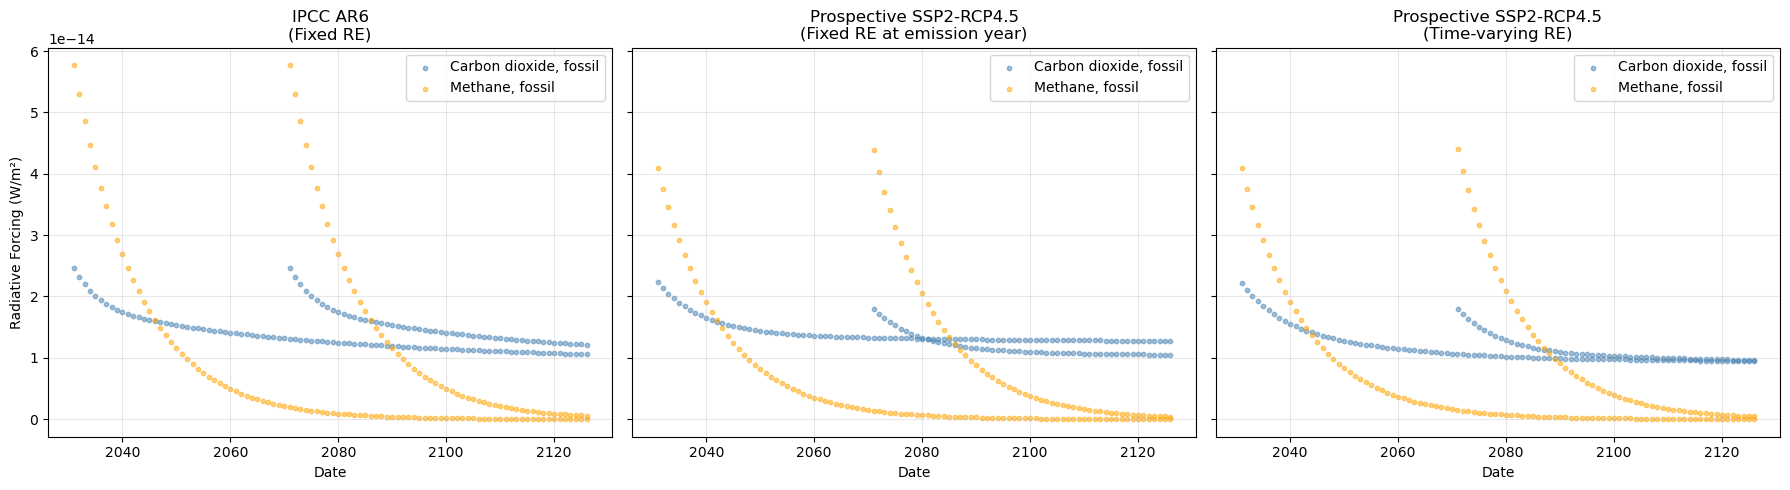

In [29]:
# plotting the 3 variants next to each other
import matplotlib.pyplot as plt

# Get flow names for legend using the remapping dict
# biosphere_map = lca.remapping_dicts["biosphere"]
# flow_names = {}
# for flow_id, key in biosphere_map.items():
#     node = bd.get_node(database=key[0], code=key[1])
#     flow_names[flow_id] = node["name"]

flow_names = {
    co2_flow.id: co2_flow["name"],
    ch4_flow.id: ch4_flow["name"]
}

# Get unique flows and colors
flows = ipcc_characterized["flow"].unique()
colors = ['steelblue', 'orange']

# Create comparison scatter plot (3 subplots) using actual dates
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# IPCC AR6 subplot
for i, flow in enumerate(flows):
    flow_data = ipcc_characterized[ipcc_characterized["flow"] == flow]
    label = flow_names.get(flow, f"Flow {flow}")
    axes[0].scatter(flow_data["date"], flow_data["amount"], 
                    alpha=0.5, s=10, color=colors[i % len(colors)], label=label)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Radiative Forcing (W/m²)")

axes[0].set_title("IPCC AR6\n(Fixed RE)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Prospective fixed RE subplot
for i, flow in enumerate(flows):
    flow_data = prospective_fixed_re[prospective_fixed_re["flow"] == flow]
    label = flow_names.get(flow, f"Flow {flow}")
    axes[1].scatter(flow_data["date"], flow_data["amount"], 
                    alpha=0.5, s=10, color=colors[i % len(colors)],  label=label) 
axes[1].set_xlabel("Date")

axes[1].set_title("Prospective SSP2-RCP4.5\n(Fixed RE at emission year)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Prospective varying RE subplot
for i, flow in enumerate(flows):
    flow_data = prospective_varying_re[prospective_varying_re["flow"] == flow]
    label = flow_names.get(flow, f"Flow {flow}")
    axes[2].scatter(flow_data["date"], flow_data["amount"], 
                    alpha=0.5, s=10, color=colors[i % len(colors)], label=label)
axes[2].set_xlabel("Date")

axes[2].set_title("Prospective SSP2-RCP4.5\n(Time-varying RE)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

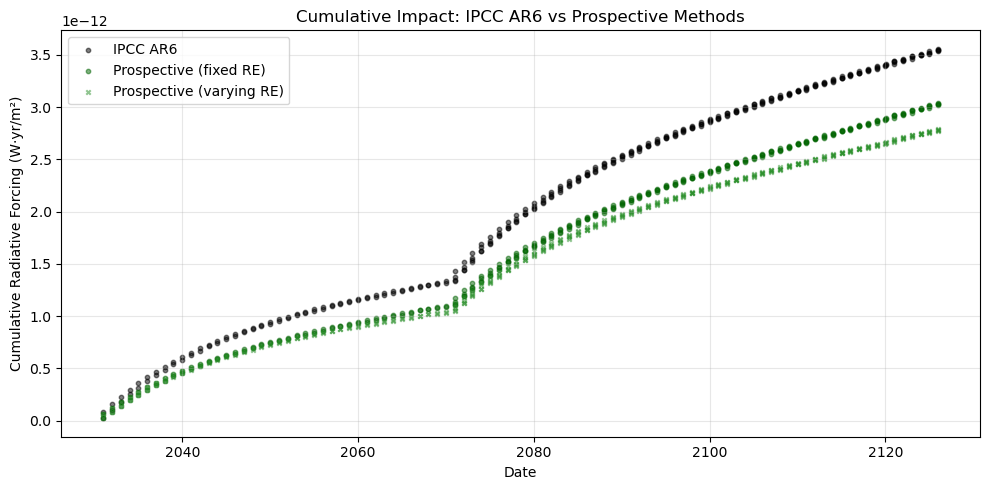


=== Summary Statistics ===
Total Cumulative RF (IPCC AR6):              3.56e-12 W·yr/m²
Total Cumulative RF (Prospective fixed RE):  3.04e-12 W·yr/m²
Total Cumulative RF (Prospective varying RE):2.79e-12 W·yr/m²

Difference (fixed RE vs IPCC):  -14.5%
Difference (varying RE vs IPCC): -21.6%


In [30]:
# Compare cumulative results
def calc_cumulative(df):
    df_sorted = df.sort_values("date").copy()
    df_sorted["cumulative"] = df_sorted["amount"].cumsum()
    return df_sorted

bw_ipcc_cumulative = calc_cumulative(ipcc_characterized)
bw_prospective_fixed_cumulative = calc_cumulative(prospective_fixed_re)
bw_prospective_varying_cumulative = calc_cumulative(prospective_varying_re)

# Plot cumulative comparison using actual dates (scatter plot)
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(bw_ipcc_cumulative["date"], bw_ipcc_cumulative["cumulative"], 
           color='black', s=10, alpha=0.5, label='IPCC AR6')
ax.scatter(bw_prospective_fixed_cumulative["date"], bw_prospective_fixed_cumulative["cumulative"], 
           color='darkgreen', s=10, alpha=0.5, label='Prospective (fixed RE)')
ax.scatter(bw_prospective_varying_cumulative["date"], bw_prospective_varying_cumulative["cumulative"], 
           color='forestgreen', s=10, alpha=0.5, marker='x', label='Prospective (varying RE)')

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Radiative Forcing (W·yr/m²)")
ax.set_title("Cumulative Impact: IPCC AR6 vs Prospective Methods")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\n=== Summary Statistics ===")
print(f"Total Cumulative RF (IPCC AR6):              {bw_ipcc_cumulative['cumulative'].iloc[-1]:.2e} W·yr/m²")
print(f"Total Cumulative RF (Prospective fixed RE):  {bw_prospective_fixed_cumulative['cumulative'].iloc[-1]:.2e} W·yr/m²")
print(f"Total Cumulative RF (Prospective varying RE):{bw_prospective_varying_cumulative['cumulative'].iloc[-1]:.2e} W·yr/m²")
print(f"\nDifference (fixed RE vs IPCC):  {((bw_prospective_fixed_cumulative['cumulative'].iloc[-1] / bw_ipcc_cumulative['cumulative'].iloc[-1]) - 1) * 100:.1f}%")
print(f"Difference (varying RE vs IPCC): {((bw_prospective_varying_cumulative['cumulative'].iloc[-1] / bw_ipcc_cumulative['cumulative'].iloc[-1]) - 1) * 100:.1f}%")

## 5. Build your own characterization function

Nothing about the `characterize()` wrapper is climate-change-specific, it just calls whatever function you map to an environmental flow. 

Let's try that by writing a characterization function for a completely different, made-up impact category: 

**seasonal water scarcity indicator**.

The idea (simplified): the same volume of water withdrawn matters more when it happens during the dry season than during the wet season. So instead of decaying over years like a GHG, our function reweights the impact based on *which month* the withdrawal happens in.

We've pre-built a dummy monthly "water stress index" for you (1 = highest stress, in July/August; lower in the wetter months) and gave the structure for characterization function. You can fill in the missing lines below.


In [ ]:
#this is a namedtuple("CharacterizedRow", ["date", "amount", "flow", "activity"]) and we want this to be the return type
from dynamic_characterization.classes import CharacterizedRow 

# illustrative monthly water stress index [Jan, Feb, Mar, .., Dec] 
water_stress_index_by_month = [0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 1.0, 1.0, 0.8, 0.6, 0.4, 0.3]

def characterize_water_scarcity(series, period: int = 1) -> CharacterizedRow:
    """A toy seasonal water scarcity characterization function"""
    month = series.date.month  

    weight =   #FILL YOURSELF

    impact =   #FILL YOURSELF

    return CharacterizedRow(
        date=np.array([series.date.to_datetime64()], dtype="datetime64[s]"),
        amount=np.array([impact], dtype="float64"),
        flow=series.flow,
        activity=series.activity,
    )


In [32]:
#Solution

#this is a namedtuple("CharacterizedRow", ["date", "amount", "flow", "activity"]) and we want this to be the return type
from dynamic_characterization.classes import CharacterizedRow 

# illustrative monthly water stress index [Jan, Feb, Mar, .., Dec] 
water_stress_index_by_month = [0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 1.0, 1.0, 0.8, 0.6, 0.4, 0.3]

def characterize_water_scarcity(series, period: int = 1) -> CharacterizedRow:
    """A toy seasonal water scarcity characterization function"""
    month = series.date.month  

    weight = water_stress_index_by_month[month - 1] 

    impact = series.amount * weight 

    return CharacterizedRow(
        date=np.array([series.date.to_datetime64()], dtype="datetime64[s]"),
        amount=np.array([impact], dtype="float64"),
        flow=series.flow,
        activity=series.activity,
    )

**Hint:**

 `series.date.month` is 1-indexed while `water_stress_index_by_month` (a python list) is  0-indexed


Now let's apply it to a dummy case: the same 100 m³ withdrawn once in January (wet season), once in May, and once in July (dry season).




**Hint:** 

You'll need a dynamic inventory `pd.DataFrame`, a mapping between elementary flow ids and the characterization function defined above, and then feed it into the `characterize`-wrapper

In [ ]:
#SOLUTION
water_inventory_df = pd.DataFrame(
    data={
        "date": pd.Series(["15-01-2026", "15-05-2026", "15-07-2026"], dtype="datetime64[s]"),
        "amount": pd.Series([100.0, 100.0, 100.0], dtype="float64"),  # m3 withdrawn
        "flow": pd.Series([10, 10, 10], dtype="int"), 
        "activity": pd.Series([1, 1, 1], dtype="int"),
    }
)

characterization_functions_water = {
    10: characterize_water_scarcity,
}

df_water_characterized = characterize(
    water_inventory_df,
    characterization_functions=characterization_functions_water,
)
df_water_characterized


import matplotlib.pyplot as plt
plt.bar(df_water_characterized["date"].dt.strftime("%b %Y"), df_water_characterized["amount"])
plt.ylabel("water scarcity impact [dummy units]")
plt.title("Same 100 m³ withdrawn, different season")
plt.show()


,date,amount,flow,activity
0,2026-01-15,20.0,10,1
1,2026-05-15,70.0,10,1
2,2026-07-15,100.0,10,1


As demonstrated with this simple example, `dynamic_characterization` cannot only be used for climate change  metrics, but is a flexible framework for any  characterization of impacts that are sensitive to timing.